# 예측 시계별 성능과 불확실성

> 2026-10-05 안내: 이 노트북의 그림·표는 오류 수정 후의 기존 실행을 다룹니다. 최신 다중 시드 결과와 현재 본문/부록 배치는 02 노트북 및 reports/baseline_benchmarks_and_future_plan.md를 참고하십시오.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
from IPython.display import display, Image
ROOT = Path.cwd()
if not (ROOT/'configs/base_config.yaml').exists(): ROOT = ROOT.parent
manifest = json.loads((ROOT/'reports/corrected_run_manifest.json').read_text(encoding='utf-8'))
run = ROOT/'models/runs'/manifest['run_id']
print(manifest['run_id'], '|', manifest['test_role'])

corrected_v3_20261004T005217+0900 | development_benchmark_previously_consulted


2025년은 사전에 참조한 개발 벤치마크입니다. 그래프의 사례 구간은 모든 horizon에 1월 10~16일로 고정했습니다. CRPS는 수치 근사이며 결정론 베이스라인의 CRPS=MAE는 확률 베이스라인 비교를 대체하지 않습니다. 경제성 지표는 실제 정산금이 아닙니다.

,horizon,count,mae,rmse,mae_median,crps,zero_auprc,zero_brier,zero_ece
0,+1h,8736,0.8018,1.2758,0.7993,0.5775,0.758931,0.071623,0.043165
10,+3h,8734,1.5816,2.3828,1.5099,1.0773,0.559593,0.094743,0.023681
20,+6h,8731,2.1049,3.2329,2.0577,1.4869,0.438798,0.113927,0.042844
30,+9h,8728,2.4423,3.5417,2.3245,1.6570,0.356436,0.124478,0.064766
40,+12h,8725,2.6776,3.8352,2.5548,1.8204,0.340481,0.123902,0.043631
50,+24h,8713,3.5322,4.4920,3.1709,2.2323,0.237648,0.135780,0.051973


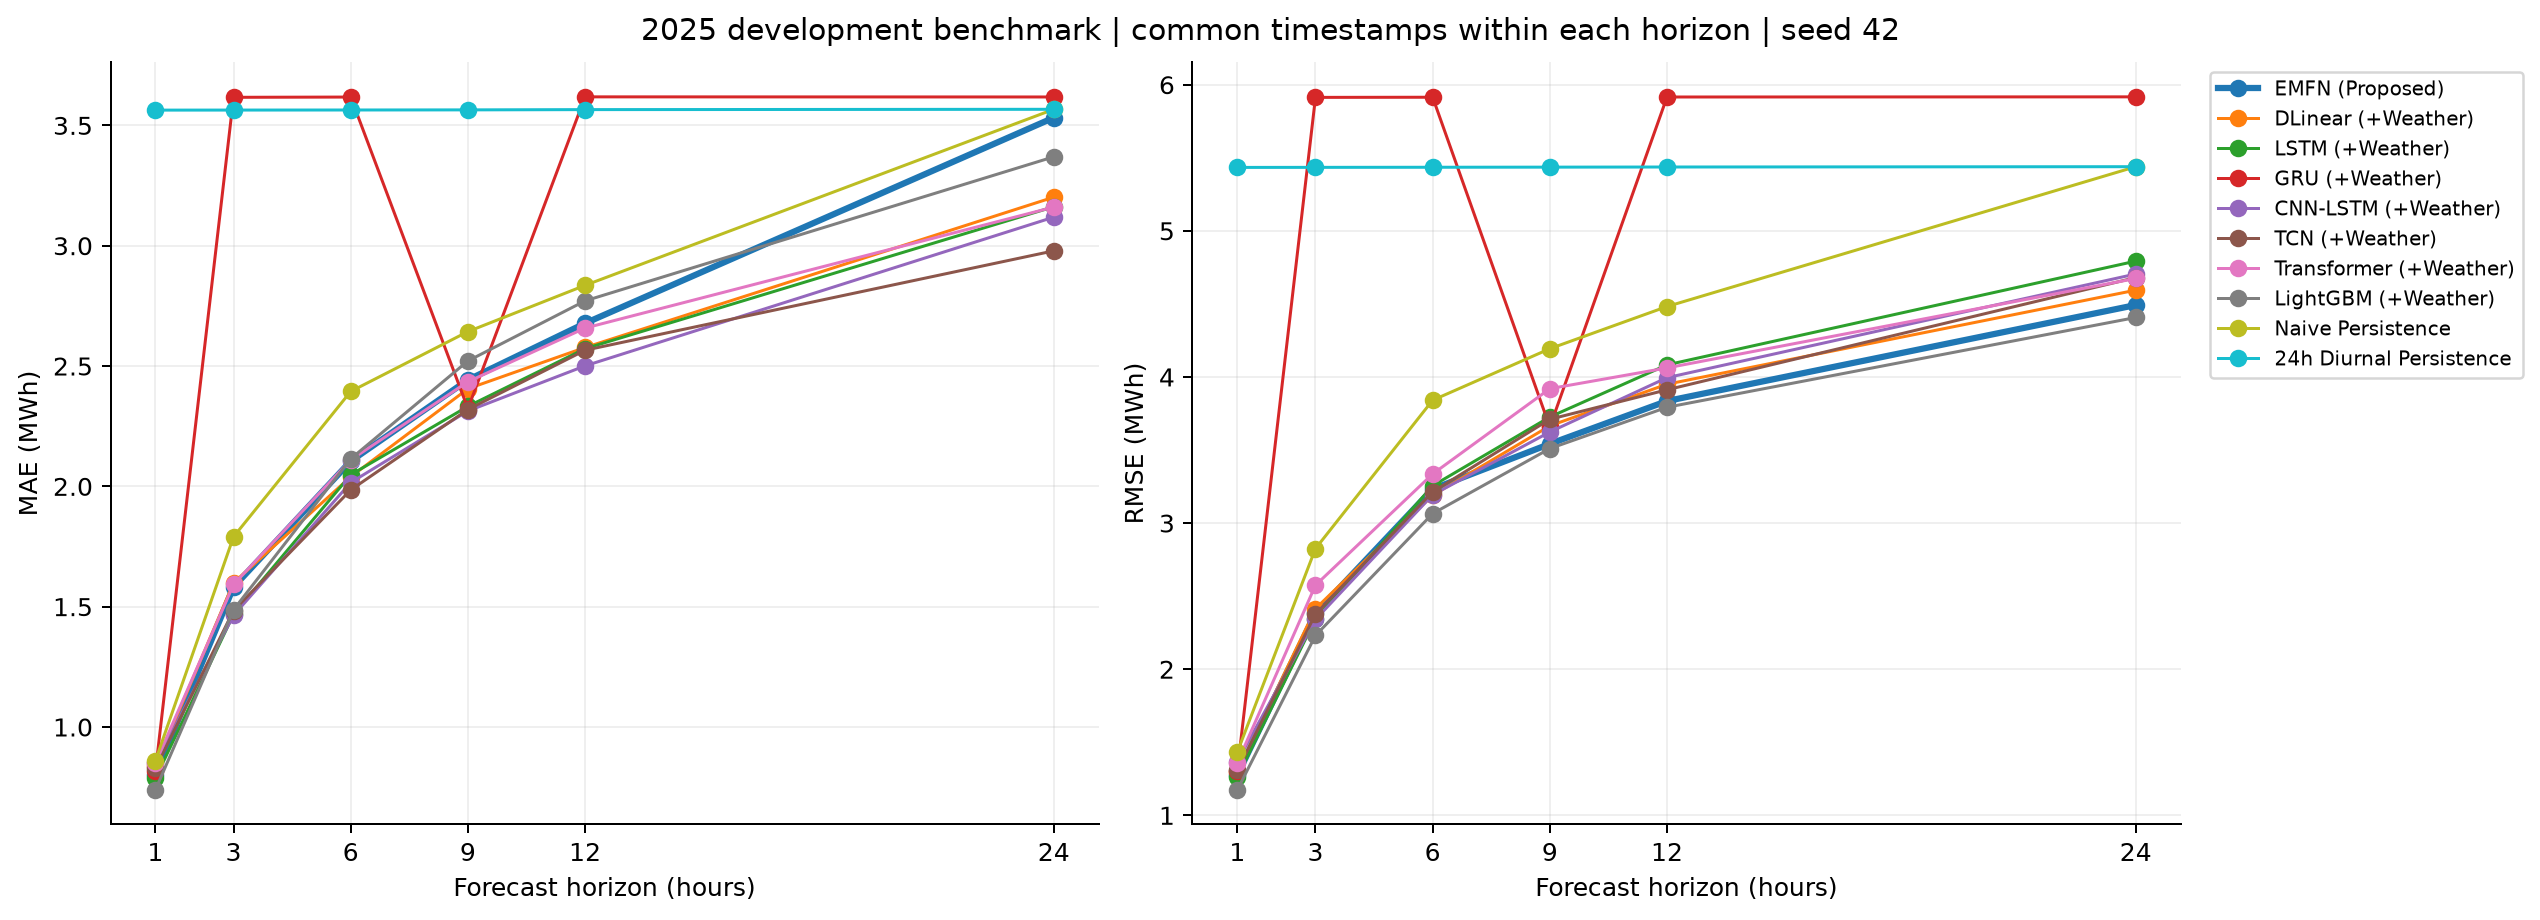

In [2]:
b=pd.read_csv(ROOT/'reports/tables/comprehensive_extended_metric_matrix.csv')
display(b[b.model.eq('EMFN (Proposed)')][['horizon','count','mae','rmse','mae_median','crps','zero_auprc','zero_brier','zero_ece']])
display(Image(filename=str(ROOT/'reports/figures/multi_horizon_performance_decay_curve.png')))

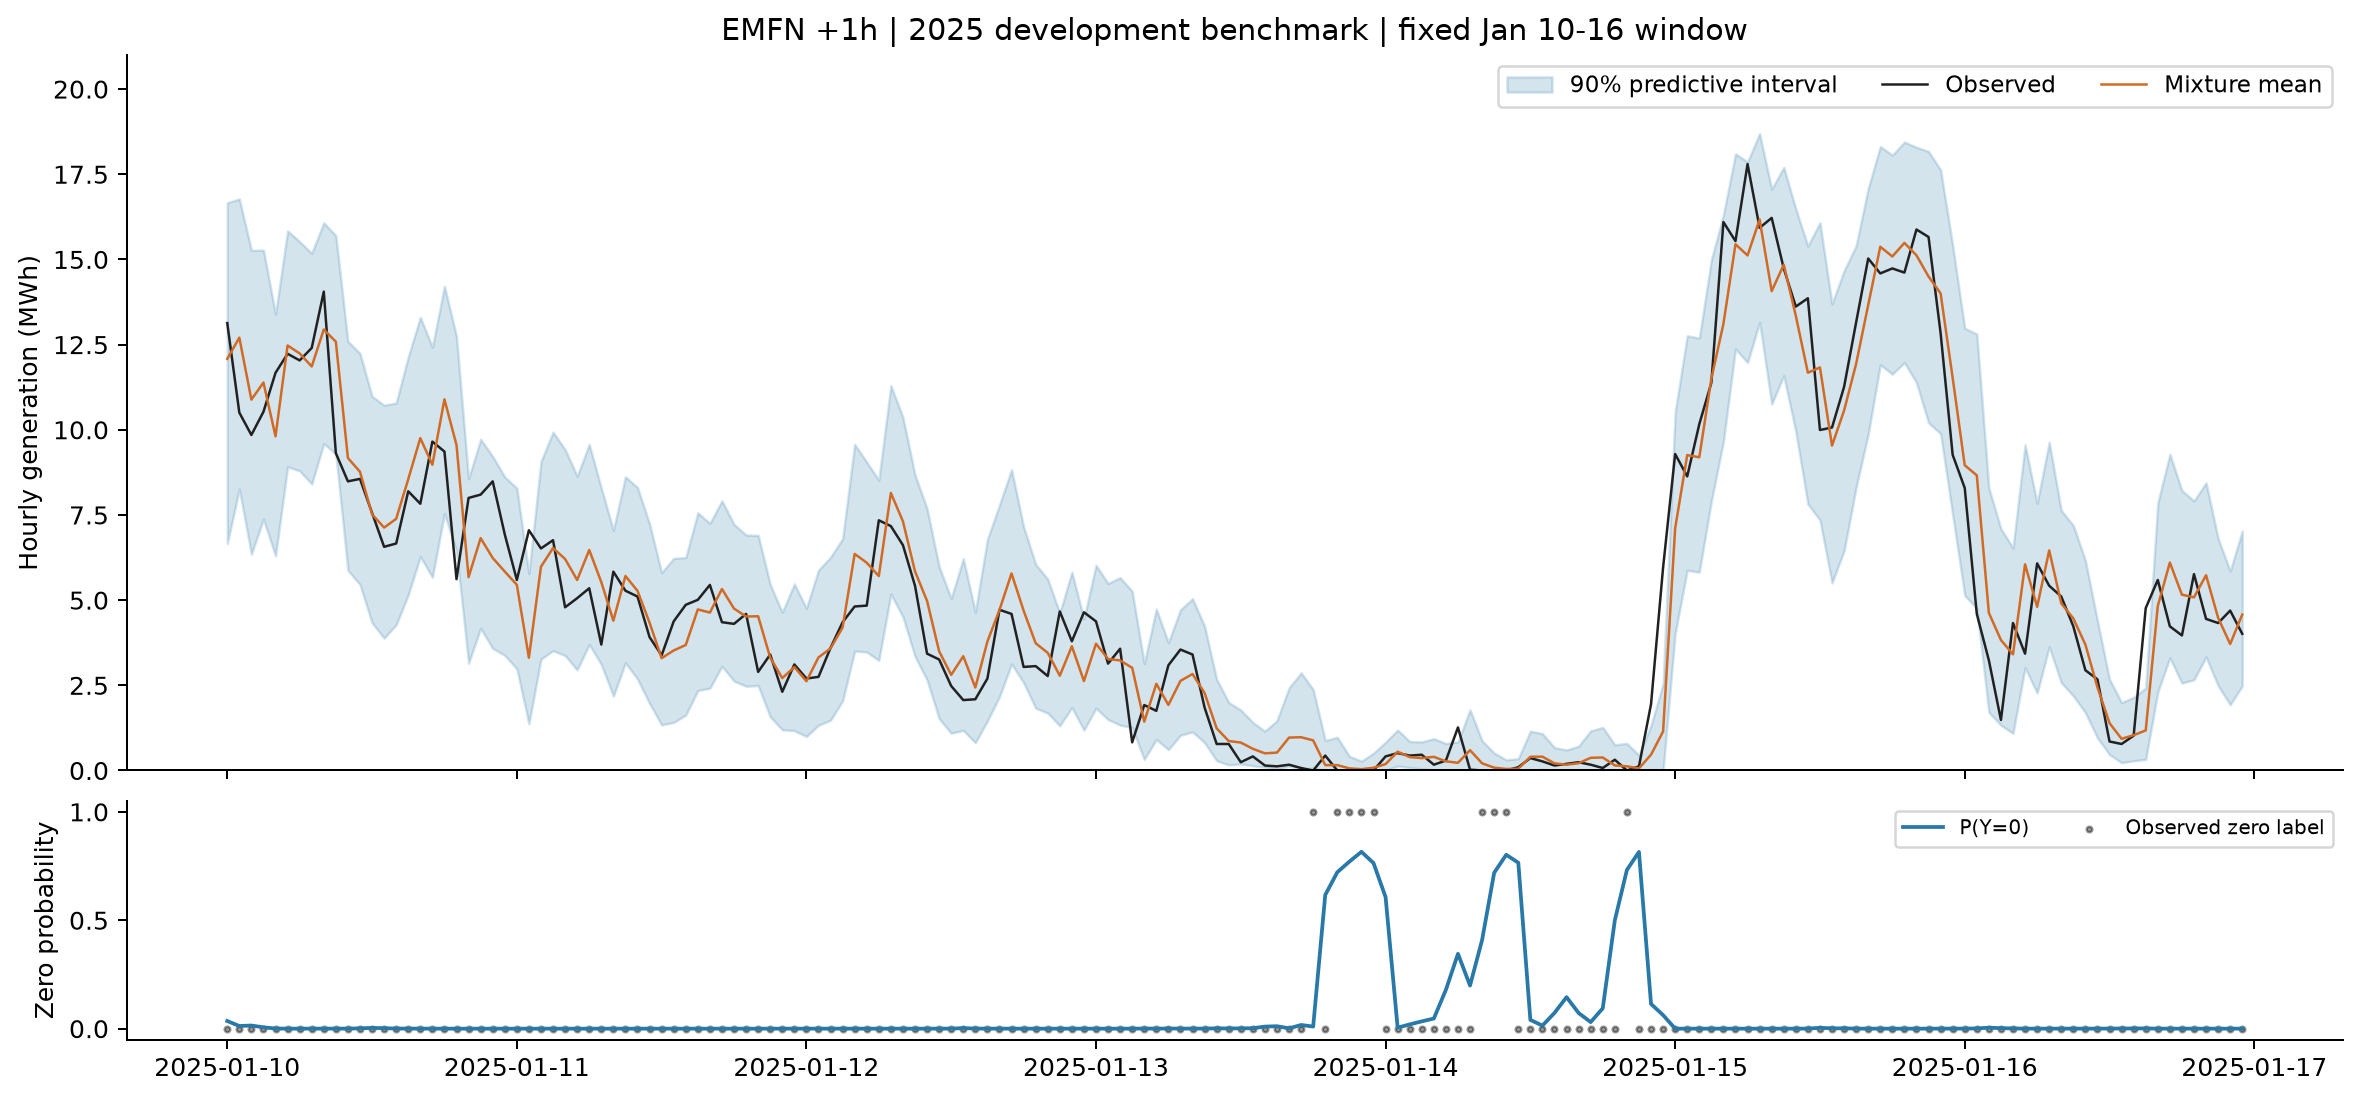

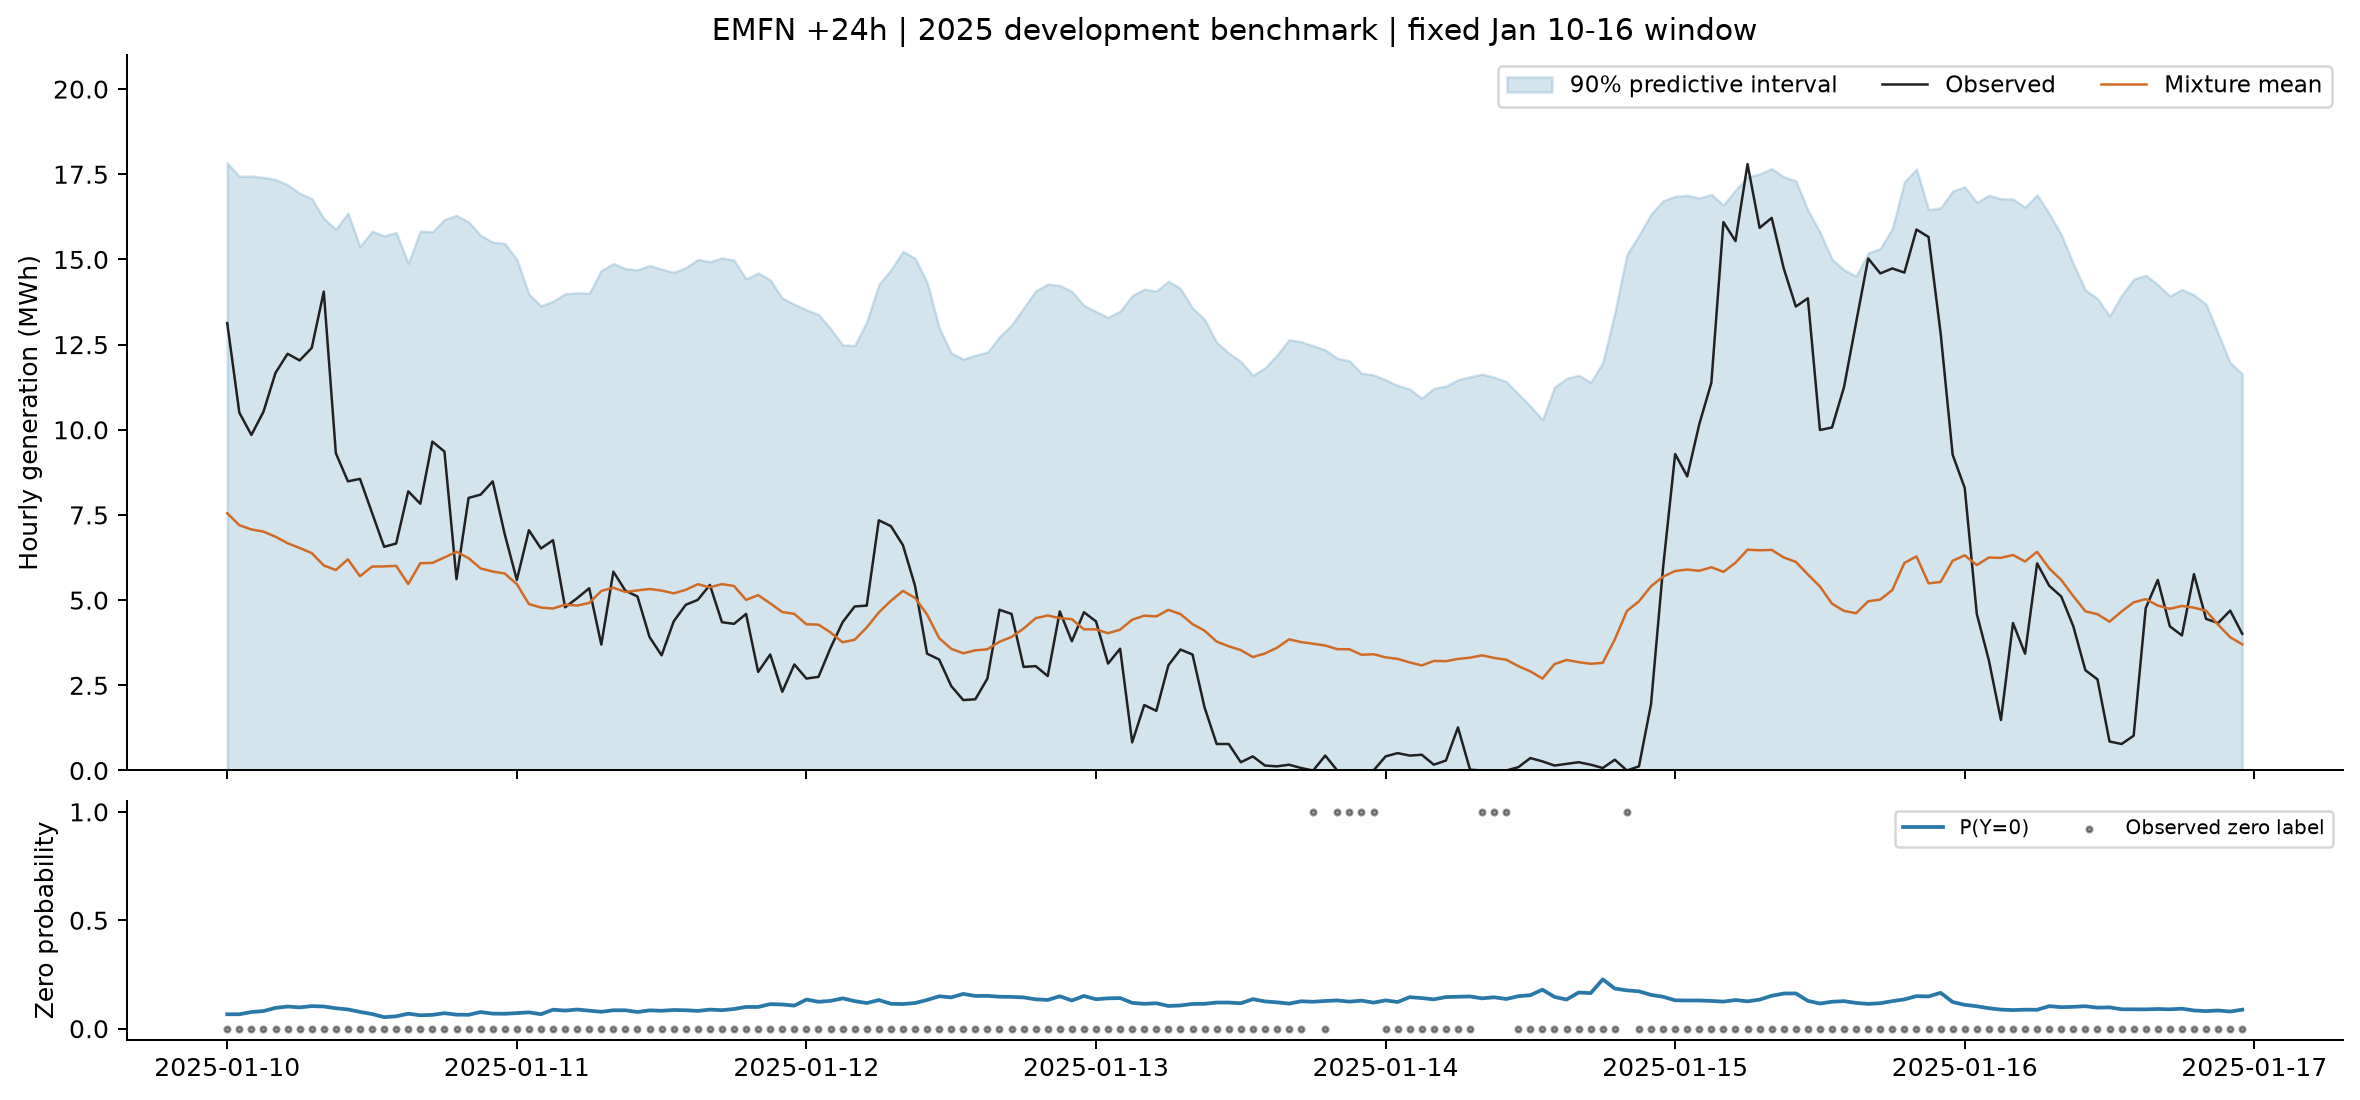

In [3]:
display(Image(filename=str(ROOT/'reports/figures/emfn_test_forecast_+1h.png')))
display(Image(filename=str(ROOT/'reports/figures/emfn_test_forecast_+24h.png')))